In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns





Total de jogos: 242
Vitórias do time 1 (team_1): 124
Vitórias do time 2 (team_2): 118
Percentual de vitórias do lado azul: 51.24%


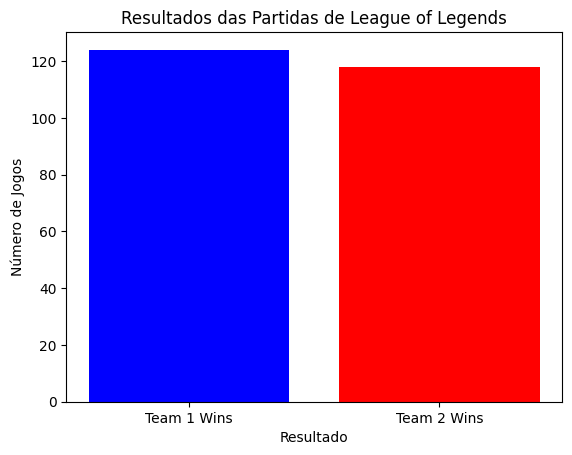

In [4]:
file_path = '../../repository/cblol/CBLOL_matches_2.csv'

# Carregar os dados organizados
df = pd.read_csv(file_path)

# Total de jogos
total_matches = df.shape[0]

# Contagem de vitórias
team_1_wins = (df['winner'] == df['team_1']).sum()
team_2_wins = (df['winner'] == df['team_2']).sum()


# Lista de valores para os times e seus resultados
win_counts = [team_1_wins, team_2_wins]

# Cálculo da porcentagem de vitórias do time 1
team_1_win_rate = (team_1_wins / total_matches) * 100

# Exibir estatísticas
print("Total de jogos:", total_matches)
print("Vitórias do time 1 (team_1):", team_1_wins)
print("Vitórias do time 2 (team_2):", team_2_wins)
print(f"Percentual de vitórias do lado azul: {team_1_win_rate:.2f}%")

# Criar gráfico de barras
x = ['Team 1 Wins', 'Team 2 Wins']
y = win_counts

plt.bar(x, y, color=['blue', 'red'])
plt.xlabel('Resultado')
plt.ylabel('Número de Jogos')
plt.title('Resultados das Partidas de League of Legends')
plt.show()


In [5]:
matches_df = pd.read_csv(file_path)
# Ordenar os dados pelas datas dos jogos para manter a ordem cronológica
# Pois temos informação temporal.
matches_df = matches_df.sort_values(by='date')
print(matches_df.head())

                  match_id           team_1          team_2 league  \
176  ESPORTSTMNT03_3087499             LOUD     paiN Gaming  CBLOL   
172  ESPORTSTMNT03_3086486          Liberty  KaBuM! Esports  CBLOL   
177  ESPORTSTMNT03_3087532      Los Grandes           Fluxo  CBLOL   
178  ESPORTSTMNT03_3087549       RED Canids            INTZ  CBLOL   
181  ESPORTSTMNT03_3088580  Vivo Keyd Stars           FURIA  CBLOL   

                    date           winner  gamelength firsttower_team  \
176  2023-01-21 16:38:16             LOUD        1440            LOUD   
172  2023-01-21 17:35:26          Liberty        2476  KaBuM! Esports   
177  2023-01-21 18:55:07      Los Grandes        1720     Los Grandes   
178  2023-01-21 19:56:12       RED Canids        1857      RED Canids   
181  2023-01-21 21:01:52  Vivo Keyd Stars        2673           FURIA   

     firstbaron_team  
176                2  
172                1  
177                0  
178                0  
181                0  


In [11]:
# Verificar se há valores nulos em todo o DataFrame
print("Contagem de valores nulos em cada coluna:")
print(matches_df.isna().sum())

# Verificar se há linhas com valores nulos e exibir essas linhas
linhas_com_na = matches_df[matches_df.isna().any(axis=1)]
if not linhas_com_na.empty:
    print("\nLinhas com valores nulos:")
    print(linhas_com_na)
else:
    print("\nNenhuma linha com valores nulos encontrada.")

# Exibir as colunas específicas que têm valores ausentes
colunas_com_na = matches_df.columns[matches_df.isna().any()]
print("\nColunas com valores ausentes:", colunas_com_na.tolist())

# Remover linhas com valores nulos em qualquer coluna e atualizar o DataFrame
matches_df = matches_df.dropna()

print("\nDataFrame atualizado sem valores nulos")

Contagem de valores nulos em cada coluna:
match_id           0
team_1             0
team_2             0
league             0
date               0
winner             0
gamelength         0
firsttower_team    0
firstbaron_team    0
dtype: int64

Nenhuma linha com valores nulos encontrada.

Colunas com valores ausentes: []

DataFrame atualizado sem valores nulos


In [12]:
# Encode team names and league
le_team = LabelEncoder()
le_league = LabelEncoder()

matches_df['game_id'] = matches_df.index
matches_df['team_1_encoded'] = le_team.fit_transform(matches_df['team_1'])
matches_df['team_2_encoded'] = le_team.fit_transform(matches_df['team_2'])
matches_df['league_encoded'] = le_league.fit_transform(matches_df['league'])
matches_df['result_encoded'] = (matches_df['winner'] == matches_df['team_1']).astype(int)
matches_df['firsttower_team_encoded'] = le_team.fit_transform(matches_df['firsttower_team'])


# Variáveis que serão usadas para treinar o modelo
# Features: (team names 1: team names 2 : league: tempo de jogo)
X = matches_df[['team_1_encoded', 'team_2_encoded', 'league_encoded', 'gamelength', 'firsttower_team_encoded', 'firstbaron_team']]

# Target: vencedor (codificado como 0 ou 1 com base em se o time_1 é o vencedor)
y = matches_df['result_encoded']

display(matches_df.head())



,match_id,team_1,team_2,league,date,winner,gamelength,firsttower_team,firstbaron_team,game_id,team_1_encoded,team_2_encoded,league_encoded,result_encoded,firsttower_team_encoded
176,ESPORTSTMNT03_3087499,LOUD,paiN Gaming,CBLOL,2023-01-21 16:38:16,LOUD,1440,LOUD,2,176,4,9,0,1,4
172,ESPORTSTMNT03_3086486,Liberty,KaBuM! Esports,CBLOL,2023-01-21 17:35:26,Liberty,2476,KaBuM! Esports,1,172,5,3,0,1,3
177,ESPORTSTMNT03_3087532,Los Grandes,Fluxo,CBLOL,2023-01-21 18:55:07,Los Grandes,1720,Los Grandes,0,177,6,1,0,1,6
178,ESPORTSTMNT03_3087549,RED Canids,INTZ,CBLOL,2023-01-21 19:56:12,RED Canids,1857,RED Canids,0,178,7,2,0,1,7
181,ESPORTSTMNT03_3088580,Vivo Keyd Stars,FURIA,CBLOL,2023-01-21 21:01:52,Vivo Keyd Stars,2673,FURIA,0,181,8,0,0,1,0


In [13]:
# Normalização dos dados de entrada (features)
scaler = MinMaxScaler().fit(X)
X_scaled = scaler.transform(X)
print('Features: ', X_scaled.shape)
print(X_scaled[:10])

Features:  (242, 6)
[[0.44444444 1.         0.         0.11603774 0.44444444 1.        ]
 [0.55555556 0.33333333 0.         0.60471698 0.33333333 0.5       ]
 [0.66666667 0.11111111 0.         0.24811321 0.66666667 0.        ]
 [0.77777778 0.22222222 0.         0.31273585 0.77777778 0.        ]
 [0.88888889 0.         0.         0.69764151 0.         0.        ]
 [0.66666667 0.77777778 0.         0.49622642 0.77777778 0.5       ]
 [0.         0.22222222 0.         0.37641509 0.22222222 0.5       ]
 [1.         0.88888889 0.         0.38584906 1.         1.        ]
 [0.33333333 0.44444444 0.         0.61132075 0.33333333 0.        ]
 [0.11111111 0.55555556 0.         0.48773585 0.55555556 0.        ]]


In [15]:
# Definir percentuais de treino, teste e previsão
# Treino      representa 80% dos dados
# Teste       representa 10% dos dados
# Previsão    representa 10% dos dados
train_ratio = 0.8
test_ratio = 0.1

# Calcular os índices para separação
total_matches = matches_df.shape[0]

train_size = int(train_ratio * total_matches)
test_size = int(test_ratio * total_matches)

# Separação manual dos dados
X_train = X_scaled[:train_size]
y_train = y[:train_size]

X_test = X_scaled[train_size:train_size + test_size]
y_test = y[train_size:train_size + test_size]

X_prediction = X_scaled[train_size + test_size:]

print(len(X_train), len(y_train))
print(len(X_test), len(y_test))


193 193
24 24


In [16]:
# Criar o modelo Naive Bayes
model = GaussianNB()

# Treinar o modelo
model.fit(X_train, y_train)

# Fazer previsões
y_pred = model.predict(X_test)

# Calcular a acurácia e f1 score
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average = 'micro')

print(f'Acurácia do modelo de Naive Bayes: {accuracy * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%%')


Acurácia do modelo de Naive Bayes: 87.50%
F1 Score: 87.50%%


In [17]:
# Criar o modelo de Regressão Logística
logistic_model = LogisticRegression()

# Treinar o modelo
logistic_model.fit(X_train, y_train)

# Fazer previsões
y_pred_logistic = logistic_model.predict(X_test)

# Calcular a acurácia e f1 score
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic, average = 'micro')

print(f'Acurácia do modelo de Regressão Logística: {accuracy_logistic * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%%')


Acurácia do modelo de Regressão Logística: 87.50%
F1 Score: 87.50%%


In [42]:
# Criar o modelo SVM
svm_model = SVC()

# Treinar o modelo SVM
svm_model.fit(X_train, y_train)

# Fazer previsões com o modelo SVM
y_pred_svm = svm_model.predict(X_test)

# Calcular a acurácia e f1 score
accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm, average = 'micro')


print(f'Acurácia do modelo SVM: {accuracy_svm * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%%')


Acurácia do modelo SVM: 87.50%
F1 Score: 87.50%%


In [43]:
# Criar o modelo de Árvore de Decisão
tree_model = DecisionTreeClassifier()

# Treinar o modelo de Árvore de Decisão
tree_model.fit(X_train, y_train)

# Fazer previsões com o modelo de Árvore de Decisão
y_pred_tree = tree_model.predict(X_test)

# Calcular a acurácia e f1 score
accuracy_tree = accuracy_score(y_test, y_pred_tree)
f1 = f1_score(y_test, y_pred_tree, average = 'micro')


print(f'Acurácia do modelo de Árvore de Decisão: {accuracy_tree * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%%')


Acurácia do modelo de Árvore de Decisão: 70.83%
F1 Score: 70.83%%


In [18]:
# Executando a previsão pelo método de maior acurácia (Naive Bayes)
prevision = X_prediction
game_id = matches_df['game_id']
game_id_prev = game_id[train_size + test_size:]

result = matches_df['result_encoded']
result_prev = result[train_size + test_size:]

pred = model.predict(prevision)



df = pd.DataFrame({'Resultado': result_prev, 'Previsão': pred, 'Game_id': game_id_prev})
print(df[:10])


     Resultado  Previsão  Game_id
147          0         1      147
148          1         1      148
149          1         1      149
151          0         0      151
150          0         0      150
154          1         1      154
155          1         1      155
156          1         0      156
157          1         0      157
152          0         0      152


<Axes: xlabel='Previsão', ylabel='Resultado'>

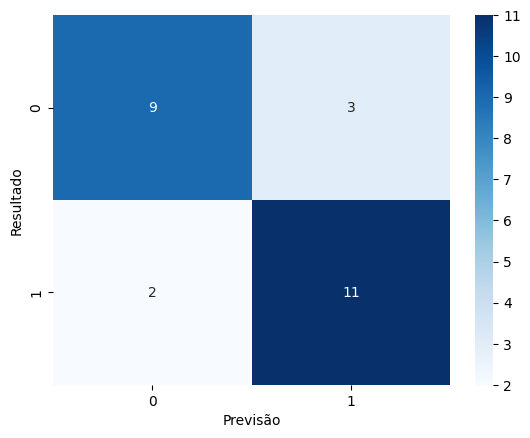

In [19]:
#Matrix de confusão
df = pd.DataFrame(df,columns = ['Resultado','Previsão'])

cf_matrix = pd.crosstab(df['Resultado'], df['Previsão'], rownames = ['Resultado'] , colnames = ['Previsão'])

sns.heatmap(cf_matrix, annot = True, cmap = 'Blues', fmt = 'g')